In [1]:
import random
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
point_number = 5_000_000

In [3]:
%%time
points = [[random.uniform(-1, 1) for i in range(0, point_number)],
          [random.uniform(-1, 1) for i in range(0, point_number)]]

point_location = []
for p in range(0, point_number):
    point_location.append((points[0][p] ** 2 + points[1][p] ** 2) < 1.0)

point_location = [int(item) for item in point_location]

pi = 4 * sum(point_location) / point_number

CPU times: total: 5.36 s
Wall time: 5.36 s


In [4]:
print('monte carlo pi: {0:.6f}'.format(pi))
print('math pi: {0:.6f}'.format(math.pi))
print('abs error: {0:.6f}'.format(abs(math.pi - pi)))

monte carlo pi: 3.139891
math pi: 3.141593
abs error: 0.001701


In [5]:
%%time

# random generator object
rng = np.random.default_rng(seed=None)

# generate numpy array of (x, y) pairs
points = rng.uniform(size=(point_number, 2), low=-1, high=1)

# find points inside circle
point_location = (points[:, 0] ** 2 + points[:, 1] ** 2 ) < 1.0
point_location = point_location.astype(int)

#estimate PI
pi = 4 * point_location.sum() / point_number 

CPU times: total: 281 ms
Wall time: 282 ms


In [6]:
print('monte carlo pi: {0:.6f}'.format(pi))
print('math pi: {0:.6f}'.format(math.pi))
print('abs error: {0:.6f}'.format(abs(math.pi - pi)))

monte carlo pi: 3.141752
math pi: 3.141593
abs error: 0.000159


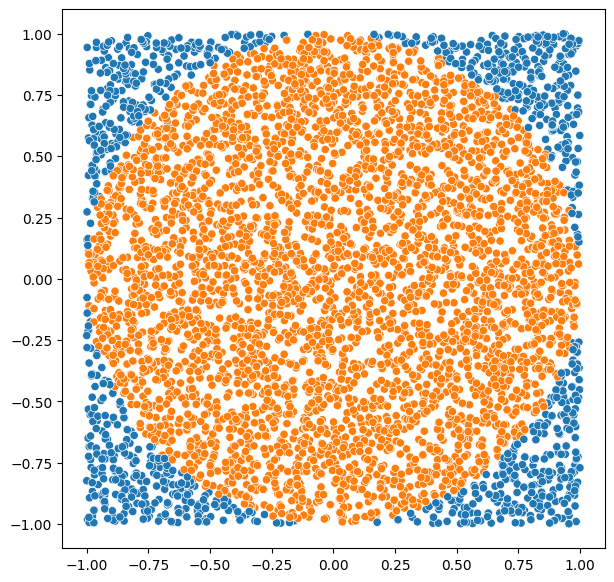

In [8]:
data = np.append(points, point_location.reshape((point_number, 1)), axis=1)
data = rng.choice(data, size=5000)

fig, axes = plt.subplots(figsize=(7, 7))
sns.scatterplot(x=data[:, 0], y=data[:, 1], hue=data[:, 2], ax=axes)
axes.get_legend().set_visible(False)